1)Considere o conjunto de dados disponível em artificial1d.csv organizado em
duas colunas, x e y. Seja um modelo de regressão linear para yˆ = f(x).

a)Apresente os parâmetros do modelo e o MSE (erro quadrático médio)
obtidos pelo algoritmo OLS (mínimos quadrados ordinários). Plote
a reta resultante sobre os dados.

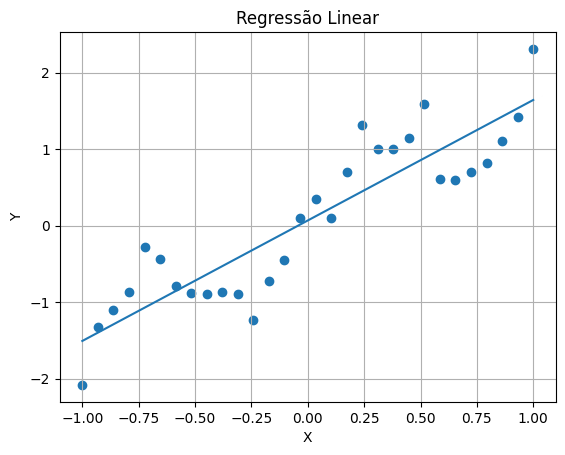

RMSE: 0.46195335406225796
w: [[0.06761792]
 [1.57486517]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

artificial1d_dataset = np.genfromtxt('./artificial1d.csv', delimiter=',')


ones = np.ones((artificial1d_dataset.shape[0], 1))

X = np.hstack((ones, artificial1d_dataset[:, [0]]))


y = artificial1d_dataset[:, [1]]


X_t = X.T
w = X_t @ X
w = np.linalg.inv(w)
w = w @ X_t
w = w @ y


y_estimado = X @ w


RMSE = y - y_estimado
RMSE = RMSE**2
RMSE = np.mean(RMSE)
RMSE = np.sqrt(RMSE)


x = artificial1d_dataset[:, 0]
y_real = artificial1d_dataset[:, 1]
y_estimado = y_estimado.flatten()


indices = np.argsort(x)

plt.scatter(x, y_real)
plt.plot(x[indices], y_estimado[indices])

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Regressão Linear')
plt.grid()

plt.show()


print("RMSE:", RMSE)
print("w:", w)

b) Apresente os parâmetros do modelo, o MSE e a curva de aprendizagem
obtidos pelo algoritmo GD (gradiente descendente). Plote a reta resultante sobre os dados.

In [11]:
import numpy as np

def normalizar_artificial1d():
    artificial1d_dataset = np.genfromtxt('./artificial1d.csv', delimiter=',')

    media = np.mean(artificial1d_dataset, axis=0)
    xi = artificial1d_dataset - media

    n = artificial1d_dataset.shape[0]
    var = np.sqrt(np.sum(xi**2, axis=0)/(n-1))

    xi_barra = xi / var

    return xi_barra
xi_barra = normalizar_artificial1d()
display(xi_barra)

def desnormalizar(valor_normalizado, media, desvio, coluna):
    return valor_normalizado * desvio[coluna] + media[coluna]


array([[-1.64708932, -2.01776249],
       [-1.53349695, -1.30904437],
       [-1.41990459, -1.10124292],
       [-1.30631222, -0.883802  ],
       [-1.19271985, -0.33101133],
       [-1.07912749, -0.4681726 ],
       [-0.96553512, -0.8094684 ],
       [-0.85194275, -0.89518064],
       [-0.73835038, -0.90816383],
       [-0.62475802, -0.87244232],
       [-0.51116565, -0.89704272],
       [-0.39757328, -1.22359975],
       [-0.28398092, -0.73889504],
       [-0.17038855, -0.48776262],
       [-0.05679618,  0.02936257],
       [ 0.05679618,  0.26409184],
       [ 0.17038855,  0.02802824],
       [ 0.28398092,  0.59377355],
       [ 0.39757328,  1.16664694],
       [ 0.51116565,  0.87685048],
       [ 0.62475802,  0.87817074],
       [ 0.73835038,  1.0151381 ],
       [ 0.85194275,  1.43105993],
       [ 0.96553512,  0.50825472],
       [ 1.07912749,  0.49448105],
       [ 1.19271985,  0.59641045],
       [ 1.30631222,  0.70934463],
       [ 1.41990459,  0.97511683],
       [ 1.53349695,

Parâmetros (w):
[[0.07051185]
 [1.57477784]]

RMSE final:
0.46196242145473837


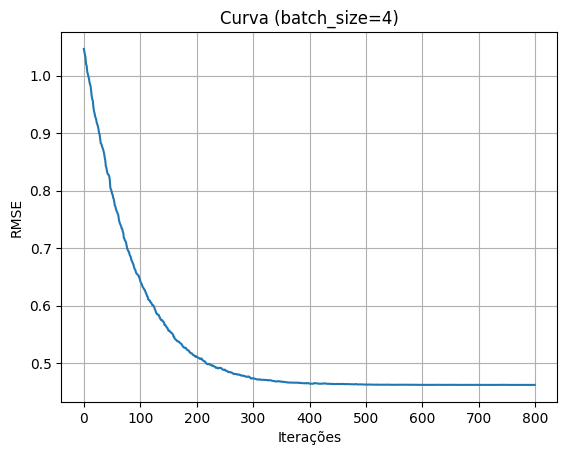

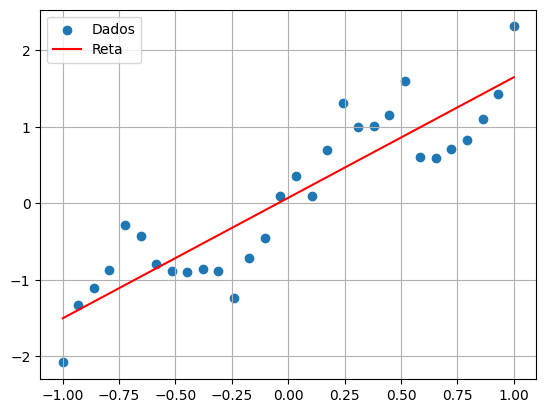

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt('./artificial1d.csv', delimiter=',')

x = data[:, 0].reshape(-1, 1)
y = data[:, 1].reshape(-1, 1)

ones = np.ones((x.shape[0], 1))
X = np.hstack((ones, x))

alpha = 0.01
epocas = 100
batch_size = 4  

w = np.zeros((2, 1))

erros = []

def RMSE(y_real, y_pred):
    return np.sqrt(np.mean((y_real - y_pred)**2))

n = X.shape[0]

for epoca in range(epocas):

    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, n, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        y_pred = X_batch @ w
        erro = y_batch - y_pred

        grad = -2 * X_batch.T @ erro / X_batch.shape[0]

        w = w - alpha * grad

        y_pred_total = X @ w
        erro_step = RMSE(y, y_pred_total)
        erros.append(erro_step)

print("Parâmetros (w):")
print(w)

print("\nRMSE final:")
print(erros[-1])

plt.plot(erros)
plt.xlabel("Iterações")
plt.ylabel("RMSE")
plt.title(f"Curva (batch_size={batch_size})")
plt.grid()
plt.show()

y_estimado = X @ w

indices = np.argsort(x.flatten())

plt.scatter(x, y, label="Dados")
plt.plot(x[indices], y_estimado[indices], color='red', label="Reta")

plt.legend()
plt.grid()
plt.show()

Questão 2
Considere o conjunto de dados disponível em california.csv, organizado em 9
colunas, sendo as 8 primeiras colunas os atributos e a última coluna a saída.
Os 8 atributos são usados na predição da mediana de preços de casas em distritos da Califórnia na década de 1990. Maiores detalhes sobre os dados podem ser conferidos em https://scikit-learn.org/stable/datasets/real_
world.html#california-housing-dataset.

a) Aleatoriamente, divida o conjunto de dados em treino (80%) e teste (20%).

In [6]:
import numpy as np

data = np.genfromtxt('./california.csv', delimiter=',')

np.random.shuffle(data)

n = data.shape[0]
n_treino = int(0.8 * n)

treino = data[:n_treino]
teste = data[n_treino:]


X_treino = treino[:, :8]
y_treino = treino[:, 8].reshape(-1, 1)


X_teste = teste[:, :8]
y_teste = teste[:, 8].reshape(-1, 1)


ones_treino = np.ones((X_treino.shape[0], 1))
X_treino = np.hstack((ones_treino, X_treino))

ones_teste = np.ones((X_teste.shape[0], 1))
X_teste = np.hstack((ones_teste, X_teste))


print("Treino X:", X_treino.shape)
print("Treino y:", y_treino.shape)
print("Teste X:", X_teste.shape)
print("Teste y:", y_teste.shape)


def normalizar(X):
    media = np.mean(X, axis=0)
    desvio = np.std(X, axis=0)
    X_norm = (X - media) / desvio
    return X_norm, media, desvio


Treino X: (800, 9)
Treino y: (800, 1)
Teste X: (200, 9)
Teste y: (200, 1)


b) Treine 13 modelos de regressão polinomial, com ordens de 1 a 13. Você
pode usar o algoritmo OLS.
c) Reporte o RMSE (raiz quadrada do erro quadrático médio) no treinamento
e no teste para cada modelo. Faça um gráfico para o treino e um gráfico
para o teste.

Grau 1: Treino RMSE = 0.8536 | Teste RMSE = 0.8334
Grau 2: Treino RMSE = 0.8500 | Teste RMSE = 0.8327
Grau 3: Treino RMSE = 0.8445 | Teste RMSE = 0.8303
Grau 4: Treino RMSE = 0.8439 | Teste RMSE = 0.8336
Grau 5: Treino RMSE = 0.8435 | Teste RMSE = 0.8331
Grau 6: Treino RMSE = 0.8415 | Teste RMSE = 0.8342
Grau 7: Treino RMSE = 0.8400 | Teste RMSE = 0.8249
Grau 8: Treino RMSE = 0.8398 | Teste RMSE = 0.8273
Grau 9: Treino RMSE = 0.8397 | Teste RMSE = 0.8292
Grau 10: Treino RMSE = 0.8397 | Teste RMSE = 0.8289
Grau 11: Treino RMSE = 0.8394 | Teste RMSE = 0.8255
Grau 12: Treino RMSE = 0.8394 | Teste RMSE = 0.8254
Grau 13: Treino RMSE = 0.8394 | Teste RMSE = 0.8253


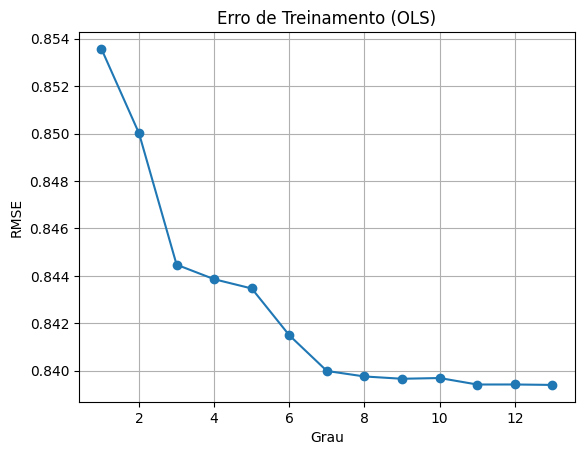

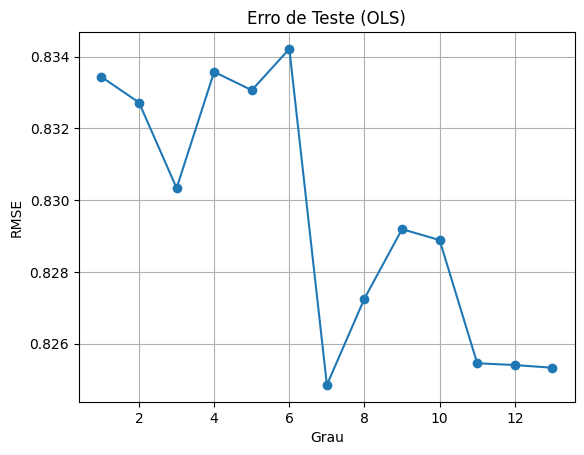

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

GRAU_MAX = 13

data = np.genfromtxt('./california.csv', delimiter=',')

np.random.shuffle(data)

n = data.shape[0]
n_treino = int(0.8 * n)

treino = data[:n_treino]
teste = data[n_treino:]

X_treino = treino[:, :8]
y_treino = treino[:, 8].reshape(-1, 1)

X_teste = teste[:, :8]
y_teste = teste[:, 8].reshape(-1, 1)

def minmax(X_treino, X_teste):
    min_val = np.min(X_treino, axis=0)
    max_val = np.max(X_treino, axis=0)

    den = max_val - min_val
    den[den == 0] = 1 

    X_treino = (X_treino - min_val) / den
    X_teste = (X_teste - min_val) / den

    return X_treino, X_teste

def standardizar(y_treino, y_teste):
    media = np.mean(y_treino)
    desvio = np.std(y_treino)

    if desvio == 0:
        desvio = 1

    y_treino = (y_treino - media) / desvio
    y_teste = (y_teste - media) / desvio

    return y_treino, y_teste, media, desvio

def desnormalizar(y, media, desvio):
    return y * desvio + media

X_treino, X_teste = minmax(X_treino, X_teste)
y_treino, y_teste, media_y, desvio_y = standardizar(y_treino, y_teste)


def gerar_polinomio(X, grau):
    x = X[:, 0].reshape(-1, 1)  
    X_poly = x

    for d in range(2, grau + 1):
        X_poly = np.hstack((X_poly, x**d))

    ones = np.ones((X_poly.shape[0], 1))
    return np.hstack((ones, X_poly))

def treinar_ols(X, y):
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def RMSE(y_real, y_pred):
    return np.sqrt(np.mean((y_real - y_pred) ** 2))

rmse_treino = []
rmse_teste = []

for grau in range(1, GRAU_MAX + 1):

    X_poly_treino = gerar_polinomio(X_treino, grau)
    X_poly_teste = gerar_polinomio(X_teste, grau)

    w = treinar_ols(X_poly_treino, y_treino)

    y_pred_treino = X_poly_treino @ w
    y_pred_teste = X_poly_teste @ w


    y_pred_treino = desnormalizar(y_pred_treino, media_y, desvio_y)
    y_pred_teste = desnormalizar(y_pred_teste, media_y, desvio_y)

    y_real_treino = desnormalizar(y_treino, media_y, desvio_y)
    y_real_teste = desnormalizar(y_teste, media_y, desvio_y)

    rmse_treino.append(RMSE(y_real_treino, y_pred_treino))
    rmse_teste.append(RMSE(y_real_teste, y_pred_teste))

for grau in range(1, GRAU_MAX + 1):
    print(f"Grau {grau}: Treino RMSE = {rmse_treino[grau-1]:.4f} | Teste RMSE = {rmse_teste[grau-1]:.4f}")

plt.plot(range(1, GRAU_MAX+1), rmse_treino, marker='o')
plt.title("Erro de Treinamento (OLS)")
plt.xlabel("Grau")
plt.ylabel("RMSE")
plt.grid()
plt.show()

plt.plot(range(1, GRAU_MAX+1), rmse_teste, marker='o')
plt.title("Erro de Teste (OLS)")
plt.xlabel("Grau")
plt.ylabel("RMSE")
plt.grid()
plt.show()

d)Repita os 2 itens anteriores incluindo um termo de regularização L2
(por exemplo, com fator λ = 0.01).

Grau 1: Treino RMSE = 0.8540 | Teste RMSE = 0.8321
Grau 2: Treino RMSE = 0.8513 | Teste RMSE = 0.8275
Grau 3: Treino RMSE = 0.8453 | Teste RMSE = 0.8272
Grau 4: Treino RMSE = 0.8453 | Teste RMSE = 0.8278
Grau 5: Treino RMSE = 0.8454 | Teste RMSE = 0.8278
Grau 6: Treino RMSE = 0.8451 | Teste RMSE = 0.8277
Grau 7: Treino RMSE = 0.8447 | Teste RMSE = 0.8275
Grau 8: Treino RMSE = 0.8444 | Teste RMSE = 0.8274
Grau 9: Treino RMSE = 0.8442 | Teste RMSE = 0.8274
Grau 10: Treino RMSE = 0.8441 | Teste RMSE = 0.8274
Grau 11: Treino RMSE = 0.8440 | Teste RMSE = 0.8275
Grau 12: Treino RMSE = 0.8440 | Teste RMSE = 0.8277
Grau 13: Treino RMSE = 0.8440 | Teste RMSE = 0.8278


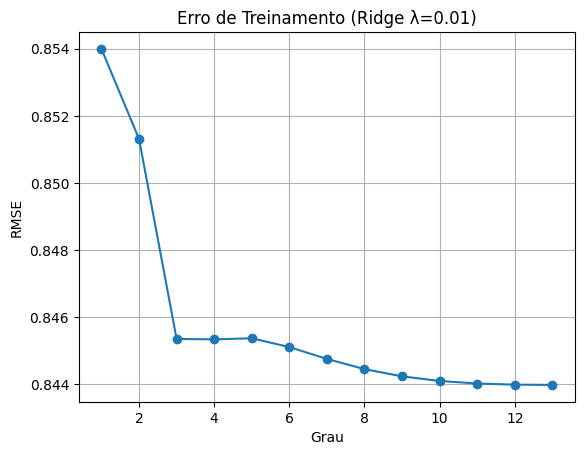

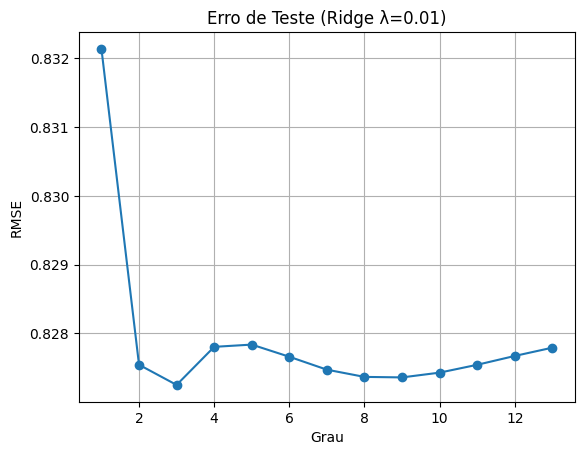

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


GRAU_MAX = 13
LAMBDA = 0.01


data = np.genfromtxt('./california.csv', delimiter=',')

np.random.shuffle(data)

n = data.shape[0]
n_treino = int(0.8 * n)

treino = data[:n_treino]
teste = data[n_treino:]


X_treino = treino[:, :8]
y_treino = treino[:, 8].reshape(-1, 1)

X_teste = teste[:, :8]
y_teste = teste[:, 8].reshape(-1, 1)


def minmax(X_treino, X_teste):
    min_val = np.min(X_treino, axis=0)
    max_val = np.max(X_treino, axis=0)

    den = max_val - min_val
    den[den == 0] = 1

    X_treino = (X_treino - min_val) / den
    X_teste = (X_teste - min_val) / den

    return X_treino, X_teste

def standardizar(y_treino, y_teste):
    media = np.mean(y_treino)
    desvio = np.std(y_treino)

    if desvio == 0:
        desvio = 1

    y_treino = (y_treino - media) / desvio
    y_teste = (y_teste - media) / desvio

    return y_treino, y_teste, media, desvio

def desnormalizar(y, media, desvio):
    return y * desvio + media

X_treino, X_teste = minmax(X_treino, X_teste)
y_treino, y_teste, media_y, desvio_y = standardizar(y_treino, y_teste)


def gerar_polinomio(X, grau):
    x = X[:, 0].reshape(-1, 1)
    X_poly = x

    for d in range(2, grau + 1):
        X_poly = np.hstack((X_poly, x**d))

    ones = np.ones((X_poly.shape[0], 1))
    return np.hstack((ones, X_poly))


def treinar_ridge(X, y, lamb):
    n_features = X.shape[1]

    I = np.eye(n_features)
    I[0, 0] = 0  # não penaliza bias

    return np.linalg.pinv(X.T @ X + lamb * I) @ X.T @ y

def RMSE(y_real, y_pred):
    return np.sqrt(np.mean((y_real - y_pred) ** 2))


rmse_treino = []
rmse_teste = []

for grau in range(1, GRAU_MAX + 1):

    X_poly_treino = gerar_polinomio(X_treino, grau)
    X_poly_teste = gerar_polinomio(X_teste, grau)

    w = treinar_ridge(X_poly_treino, y_treino, LAMBDA)

    y_pred_treino = X_poly_treino @ w
    y_pred_teste = X_poly_teste @ w

    y_pred_treino = desnormalizar(y_pred_treino, media_y, desvio_y)
    y_pred_teste = desnormalizar(y_pred_teste, media_y, desvio_y)

    y_real_treino = desnormalizar(y_treino, media_y, desvio_y)
    y_real_teste = desnormalizar(y_teste, media_y, desvio_y)

    rmse_treino.append(RMSE(y_real_treino, y_pred_treino))
    rmse_teste.append(RMSE(y_real_teste, y_pred_teste))


for grau in range(1, GRAU_MAX + 1):
    print(f"Grau {grau}: Treino RMSE = {rmse_treino[grau-1]:.4f} | Teste RMSE = {rmse_teste[grau-1]:.4f}")

plt.plot(range(1, GRAU_MAX+1), rmse_treino, marker='o')
plt.title(f"Erro de Treinamento (Ridge λ={LAMBDA})")
plt.xlabel("Grau")
plt.ylabel("RMSE")
plt.grid()
plt.show()

plt.plot(range(1, GRAU_MAX+1), rmse_teste, marker='o')
plt.title(f"Erro de Teste (Ridge λ={LAMBDA})")
plt.xlabel("Grau")
plt.ylabel("RMSE")
plt.grid()
plt.show()